#Restaurant Tip Analysis

In [19]:
##Data Overview

import pandas as pd

url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df=pd.read_csv(url)
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [17]:
##Data Cleaning

df.isnull().sum()
df.duplicated().sum()

np.int64(1)

In [18]:
##Analysis

df.groupby("day")["tip"].mean()
df.groupby("size")["tip"].mean()

,tip
size,
1,1.437500
2,2.582308
3,3.393158
4,4.135405
5,4.028000
6,5.225000


In [10]:
df[df["tip"]>5]

,total_bill,tip,sex,smoker,day,time,size
23,39.42,7.58,Male,No,Sat,Dinner,4
44,30.40,5.60,Male,No,Sun,Dinner,4
47,32.40,6.00,Male,No,Sun,Dinner,4
52,34.81,5.20,Female,No,Sun,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
85,34.83,5.17,Female,No,Thur,Lunch,4
88,24.71,5.85,Male,No,Thur,Lunch,2
116,29.93,5.07,Male,No,Sun,Dinner,4
141,34.30,6.70,Male,No,Thur,Lunch,6
155,29.85,5.14,Female,No,Sun,Dinner,5


In [11]:
df.groupby(["day","size"])["tip"].mean().sort_values(ascending=False)

day   size
Thur  6       5.300000
Sun   6       5.000000
Thur  5       5.000000
Fri   4       4.730000
Thur  4       4.218000
Sat   4       4.123846
Sun   4       4.087778
      5       4.046667
Sat   3       3.797778
Sun   3       3.120667
Fri   3       3.000000
Sat   5       3.000000
Sun   2       2.816923
Thur  3       2.692500
Fri   2       2.644375
Sat   2       2.517547
Thur  2       2.442500
Fri   1       1.920000
Thur  1       1.830000
Sat   1       1.000000
Name: tip, dtype: float64

In [12]:
df.sort_values(by="tip",ascending=False).head(10)

,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
23,39.42,7.58,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
141,34.30,6.70,Male,No,Thur,Lunch,6
183,23.17,6.50,Male,Yes,Sun,Dinner,4
214,28.17,6.50,Female,Yes,Sat,Dinner,3
47,32.40,6.00,Male,No,Sun,Dinner,4
239,29.03,5.92,Male,No,Sat,Dinner,3
88,24.71,5.85,Male,No,Thur,Lunch,2


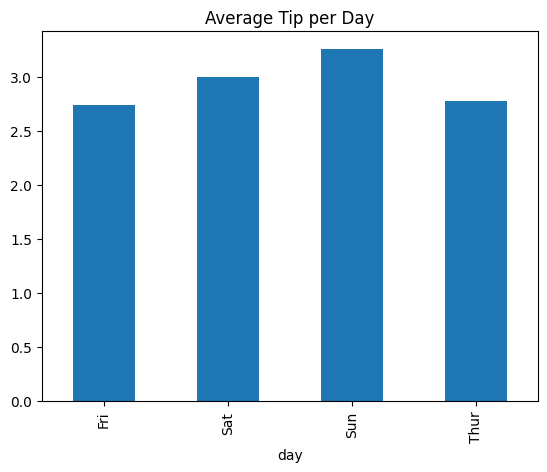

In [16]:
##Visualization

import matplotlib.pyplot as plt

df.groupby("day")["tip"].mean().plot(kind="bar")
plt.title("Average Tip per Day")
plt.show()


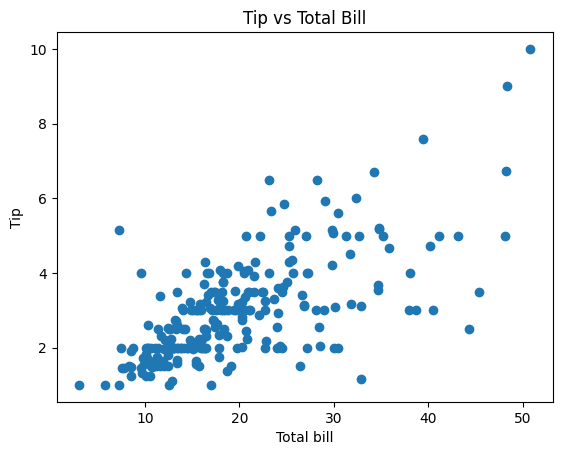

In [15]:
plt.scatter(df["total_bill"],df["tip"])
plt.title("Tip vs Total Bill")
plt.xlabel("Total bill")
plt.ylabel("Tip")
plt.show()

##Insights

-Thursday shows the highest average tip, indicating that customers turned to be more generous on this day compared than others.

-Sunday has the hihgest number of customers, making it the busiest day. However, high traffic does not necessarily translate to the highest average tips.

-Larger groups, particularly group size 6, tend to give higher average tips, suggesting that the group dinning maybe influence tipping behavior.

-We focusing on higher-value tips (greater than 5), Sunday appears most frequently, while group size 4 is the most common.

-Among top 10 highest tips, Saturday appears most frequently and group size 4 is the most common. This suggest that Saturday generate many of the highest individual tips, aspecially from mid-sized groups.

-There is a positive relatioship between total bill and tip amount. Customers who spend more generally leave higher tips as observed from the scatter plot.

-Overall, tipping behavior varies across days and group sizes, with both timing(day of the week) and customer characteristics(group size and spending) influencing outcomes.   

##Recommendations

-Focus marketing and promotional effors on Thursday, as this day shows the highest average tipping behavior.

-Allocate more staff and resources on Sunday to efficiently manage the higher customer volume.

-Target mid-sized groups(around 4 people) as they consistently appear among high-value and top tipping customers.

-Encourage high customer spending through upselling strategies, as higher total bills are associated with higher tips.

-Leverage Saturdays for revenue opportunities, as they generate many of the highest individual tips.

-Design customer experience strategies that cater to both high-volume days(Sunday) and high-value tipping periods(Thursday and Saturday)